In [1]:
import math
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import poisson
from patsy import dmatrices
import statsmodels.graphics.tsaplots as tsa
from matplotlib import pyplot as plt
from statsmodels.tools.numdiff import approx_hess1, approx_hess2, approx_hess3
import scipy.optimize as opt

In [2]:
def GP1_pmf(y, mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( 1/math.exp((mu + alpha*y) ) * mu * ( (mu + alpha*y)**(y-1) ) ) / (math.factorial(y))

def GP1_mean(mu, alpha):
        if(alpha == 1 ):
                return ( mu ) / (0.9)
        else:
                return ( mu ) / (1-alpha)

def GP1_var(mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( mu ) / (1-alpha)**3

In [3]:
GP1_pmf(4,3,1)

0.03909693927314988

In [4]:
class GP1HMM(GenericLikelihoodModel):
    #endog:Yt; exog: X list of emission; k: #state; covariate:corvariate list of transtion matrix;
    #length: list of mutlti time serial data length, e.g. [15,22,30]; extra_params_names: name of parameters
    def __init__(self, endog, exog, k_regimes=2, covariate = None , length=None,loglike=None, score=None, hessian=None,
                 missing='none', extra_params_names=None, **kwds):
        super(GP1HMM, self).__init__(endog=endog, exog=exog, loglike=loglike, score=score,
                                         hessian=hessian, missing=missing,
                                         extra_params_names=extra_params_names, kwds=kwds)
        #Initialize all variable

        self.y = np.array(self.endog)
        self.k_regimes = k_regimes
        if covariate is not None:
            self.covariate = np.array(covariate)
        if length is not None:
            self.length = np.array(length)
        else:
            self.length = None
        
        # 1 x (k_regimes-1) proxy of initial state probability matrix
        self.initial_state_matrix = np.ones([1, self.k_regimes-1])/k_regimes

        #k_regimes x corvariate.shape[1] size matrix of regime specific self-recurrent regression coefficients
        self.covariate_beta_matrix = np.ones([self.k_regimes, self.covariate.shape[1] ])

        # k x (k-2) matrix of psuedo transition probabilities which can range from -inf to +inf during
        # optimization. Initialized to 1.0/k-2
        if self.k_regimes>2:
            self.q_matrix = np.ones([self.k_regimes,(self.k_regimes-2)])*(1.0/ (self.k_regimes-2) )

        #k_regimes x exog.shape[1] size matrix of regime specific regression coefficients
        self.beta_matrix = np.ones([self.k_regimes, self.exog.shape[1]])

        #The regime wise matrix of Poisson means. These would be updated during the optimization
        # loop
        self.mu_matrix = []

        #The GP2 dispersion parameter.
        self.alpha = np.zeros([self.k_regimes,1])

        # (t-1) x k x k matrix of the real Markov transition probabilities which will be calculated from
        # the q-matrix using a standardization technique. Initialized to 1.0/k
        self.gamma_matrix = np.ones([self.exog.shape[0]-1, self.k_regimes, self.k_regimes])*(1.0/self.k_regimes)

        # The Markov state probabilities. Also referred to as pi. but we'll use delta since pi is
        # often used to refer to the mean
        self.delta_matrix = np.ones([self.exog.shape[0],self.k_regimes])*(1.0/self.k_regimes)

        #A very tiny number (machine specific). Used by the LL function.
        self.EPS = np.MachAr().eps

        #Optimization iteration counter
        self.iter_num=0

        #The vector of initial values for all the parameters, beta and q, that the optimizer will
        # optimize
        self.start_params = self.beta_matrix.flatten()
        self.start_params = np.append(self.start_params, self.initial_state_matrix.flatten())
        self.start_params = np.append(self.start_params, self.covariate_beta_matrix.flatten())
        self.start_params = np.append(self.start_params, self.alpha.flatten())

        if k_regimes>2:
            self.start_params = np.append(self.start_params, self.q_matrix.flatten())

        self.ll_history = np.zeros([1,1])
        self.params_history = np.zeros([1,len(self.start_params)])

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeobs(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeopt(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll.sum()

    # Reconstitute the q and beta matrices from the current values of all the params
    def reconstitute_parameter_matrices(self, params):
        index = 0

        self.beta_matrix = params[ : self.k_regimes*self.exog.shape[1] ]
        self.beta_matrix = self.beta_matrix.reshape([self.k_regimes, self.exog.shape[1] ]) 
        index = index + self.k_regimes*self.exog.shape[1]
        
        self.initial_state_matrix = params[index : index + self.k_regimes - 1 ]
        self.initial_state_matrix = self.initial_state_matrix.reshape([1, self.k_regimes-1])
        index = index + self.k_regimes - 1

        self.covariate_beta_matrix = params[index : index + self.k_regimes * self.covariate.shape[1]]
        self.covariate_beta_matrix = self.covariate_beta_matrix.reshape([self.k_regimes, self.covariate.shape[1] ])
        index = index + self.k_regimes * self.covariate.shape[1]
            
        if self.k_regimes>2:
            self.q_matrix = params[index : index + self.k_regimes*(self.k_regimes-2)]
            self.q_matrix = self.q_matrix.reshape([self.k_regimes, (self.k_regimes-2)])
            index = index + self.k_regimes * self.k_regimes
        
        self.alpha = params[index : index + self.k_regimes]
        self.alpha = self.alpha.reshape([self.k_regimes,1])

        


    # Build the regime wise matrix of Poisson means
    def compute_regime_specific_poisson_means(self):
        self.mu_matrix = []
        '''for k in range(1, self.k_regimes):
            self.beta_matrix[k][0] += np.exp(self.beta_matrix[k-1][0])'''

        for j in range(self.k_regimes):
            #Fetch the regression coefficients vector corresponding to the jth regime
            beta_j = self.beta_matrix[j]

            #Compute the Poisson mean and variance
            mu_j = np.exp(self.exog.dot(beta_j))
 

            if len(self.mu_matrix) == 0:
                self.mu_matrix = mu_j
            else:
                self.mu_matrix = np.vstack((self.mu_matrix,mu_j))


                
        self.mu_matrix = self.mu_matrix.transpose()
    
    # Compute the GP1 dispersion parameter
    def compute_GP1_alpha(self):

        N = len(self.y)*self.k_regimes
        k = self.beta_matrix.shape[1]
        sum = 0

        for i in range(self.k_regimes):
            for j in range(len(self.y)):
                sum += ( np.abs(self.y[j] - self.mu_matrix[j][i]) / ( (self.mu_matrix[j][i])**(1/2) ) - 1 )* (self.mu_matrix[j][i]**(-1))
            self.alpha[i] = sum / (N-k-1)


            
            if(self.alpha[i] <= (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) ):    
                self.alpha[i] = (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) + np.MachAr().eps
            elif(self.alpha[i] >= 1 ):
                self.alpha[i] = 1
        






    # Build the matrix of Markov transition probabilities by computing self-recurrent and non-recurrent state probabilities
    def compute_markov_transition_probabilities(self):
        
        # t x k recurrent matrix compute state k transition to itself in every time t
        self.recurrent_matrix = (self.covariate.dot(self.covariate_beta_matrix.transpose()))
        for t in range(self.exog.shape[0]-1):
            for i in range(self.k_regimes):
                for j in range(self.k_regimes):
                    if(i==j):
                        if(self.recurrent_matrix[t][j]>=709):
                            self.recurrent_matrix[t][j]=709
                        self.gamma_matrix[t][i][j] = math.exp(self.recurrent_matrix[t][j]) /( 1 + math.exp(self.recurrent_matrix[t][j]) )

        # If k=2, there's no need to use q_matrix
        if(self.k_regimes==2):
            for t in range(self.exog.shape[0]-1):
                for i in range(self.k_regimes):
                    for j in range(self.k_regimes):
                        if(i!=j):
                            self.gamma_matrix[t][i][j] = 1 - self.gamma_matrix[t][i][i]
        else:
            for t in range(self.exog.shape[0]-1):
                #Using  q to compute transtion probability which is not self-recurrent
                for i in range(self.k_regimes):
                    denom = 1
                    count = 0
                    for r in range(self.k_regimes-2):
                        denom += math.exp(self.q_matrix[i][r])
                        
                    for j in range(self.k_regimes):            
                        if(i==j ):continue
                        else:
                            if(count < self.k_regimes-2):
                                self.gamma_matrix[t][i][j] =( math.exp(self.q_matrix[i][count])/denom)*(1-self.gamma_matrix[t][i][i])
                                count+=1
                            else:
                                self.gamma_matrix[t][i][j] = (1.0/denom)*(1-self.gamma_matrix[t][i][i])

    # Build the (t x k) matrix delta of Markov state probabilities distribution. k state
    # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
    def compute_markov_state_probabilities(self):
        #Compute initial state probability
        denom = 1
        for r in range(self.k_regimes-1):
            if(self.initial_state_matrix[0][r]>709):
                self.initial_state_matrix[0][r] = 709
            denom += math.exp(self.initial_state_matrix[0][r])
            
        for j in range(self.k_regimes-1):
            self.delta_matrix[0][j] = math.exp(self.initial_state_matrix[0][j])/denom
        self.delta_matrix[0][self.k_regimes-1] = 1.0/denom

        #Compute state probabilties in each time t seperately if there's multiple time serial data.
        if(self.length is not None):
            index = 1
            for n in range(len(self.length)):
                for t in range(index, index + self.length[n] - 1):
                    self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])
                index += self.length[n]
                if (index-1) < len(self.y):
                    self.delta_matrix[index-1]= self.delta_matrix[0]
        else:
            for t in range(1, len(self.y)):
                self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])


    # Compute all the log-likelihood values for the Poisson Markov model
    def compute_loglikelihood(self):
        #Init the list of loglikelihhod values, one value for each y observation
        ll = []
        for t in range(len(self.y)):
            prob_y_t = 0
            mu_t = 0
            for j in range(self.k_regimes):
                #To use the law of total probability, uncomment this row and comment out the next
                # two rows

                prob_y_t += GP1_pmf(self.y[t], GP1_mean(self.mu_matrix[t][j], self.alpha[j]) , self.alpha[j] ) * self.delta_matrix[t][j]
                #Calculate the Poisson mean mu_t as an expectation over all Markov state
                # probabilities
                #mu_t += self.mu_matrix[t][j] * self.delta_matrix[t][j]
                #prob_y_t += poisson.pmf(self.y[t], mu_t)

            #This is a bit of a kludge. If the likelihood turns out to be real tiny, fix it to
            # the EPS value for the machine
            if prob_y_t < self.EPS:
                prob_y_t = self.EPS
            #Push the LL into the list of LLs
            ll.append(math.log(prob_y_t))
        ll = np.array(ll)
        return ll
    
    #Decode state path
    def decode(self):
        #decoded state path matrix: t
        self.decode_matrix = np.ones([len(self.y)])
        for t in range( len(self.y) ):
            max = 0
            state = 0
            for k in range(self.k_regimes):
                if(k == 0):
                    max = self.delta_matrix[t][k]
                    state = state + 1
                else:
                    if(self.delta_matrix[t][k] > max):
                        state = state + 1
                        max = self.delta_matrix[t][k]
            self.decode_matrix[t] = state

    #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
    # using selection sort.
    def sort(self):
        for i in range(self.k_regimes-1):
            minimum = i
            for j in range(i+1,self.k_regimes):
                if( self.beta_matrix[minimum][0] > self.beta_matrix[j][0] ):
                    minimum = j
            if(minimum != i):
                self.beta_matrix = list(self.beta_matrix)
                self.beta_matrix[minimum], self.beta_matrix[i] =  self.beta_matrix[i], self.beta_matrix[minimum]
                self.beta_matrix = np.array(self.beta_matrix)

                self.covariate_beta_matrix = list(self.covariate_beta_matrix)
                self.covariate_beta_matrix[minimum], self.covariate_beta_matrix[i] = self.covariate_beta_matrix[i], self.covariate_beta_matrix[minimum]
                self.covariate_beta_matrix = np.array(self.covariate_beta_matrix)

                self.delta_matrix = list(self.delta_matrix)
                self.mu_matrix = list(self.mu_matrix)

                for t in range(len(self.y)):
                    self.delta_matrix[t][minimum], self.delta_matrix[t][i] =  self.delta_matrix[t][i], self.delta_matrix[t][minimum]
                    self.mu_matrix[t][minimum], self.mu_matrix[t][i] =  self.mu_matrix[t][i], self.mu_matrix[t][minimum]
                self.delta_matrix = np.array(self.delta_matrix)
                self.mu_matrix = np.array(self.mu_matrix)

                self.gamma_matrix = list(self.gamma_matrix) 
                for t in range(len(self.y)-1):
                    self.gamma_matrix[t][minimum][minimum], self.gamma_matrix[t][i][i] = self.gamma_matrix[t][i][i], self.gamma_matrix[t][minimum][minimum]
                    self.gamma_matrix[t][minimum][i], self.gamma_matrix[t][i][minimum] = self.gamma_matrix[t][i][minimum], self.gamma_matrix[t][minimum][i]
                self.gamma_matrix = np.array(self.gamma_matrix)

In [5]:
k_regimes = 2

In [6]:
import pandas as pd
strikes_data = pd.read_csv(R'StrikeNb.csv')


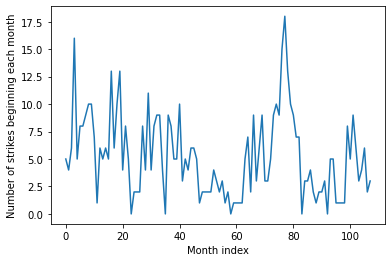

In [7]:
#strikes_dataset = sm.datasets.get_rdataset(dataname="StrikeNb", package = "Ecdat")
#strikes_data = strikes_dataset.data

#Plot the number of strikes starting each month
plt.xlabel('Month index')
plt.ylabel('Number of strikes beginning each month')
strikes_data['strikes'].plot()
plt.show()

In [8]:
strikes_data['strikes_lag1'] = strikes_data['strikes'].shift(1)
strikes_data = strikes_data.dropna()

def indicator_func(x):
    if x == 0:
        return 1
    else:
        return 0

strikes_data['d1'] = strikes_data['strikes_lag1'].apply(indicator_func)
strikes_data['strikes_adj_lag1']=np.maximum(1,strikes_data['strikes_lag1'])
strikes_data['ln_strike_adj_lag1']=np.log(strikes_data['strikes_adj_lag1']) 

expr = 'strikes ~ output + ln_strike_adj_lag1 + d1'
y_train, x_train = dmatrices(expr, strikes_data, return_type='dataframe')

In [9]:
cor = 'strikes ~ output + ln_strike_adj_lag1 + d1 '
y, covariate = dmatrices(cor, strikes_data, return_type='dataframe')

In [10]:
k_regimes = 2
extra_params_names = []

for regime_num in range(1, k_regimes):
    for param_name in x_train.columns:
        extra_params_names.append(param_name+'_R'+str(regime_num))

for k in range(k_regimes-1):
    extra_params_names.append('Initial state_'+str(k))

for regime_num in range(k_regimes):
#    extra_params_names.append("Intercept_"+str(regime_num))
    for param_name in covariate.columns:
        extra_params_names.append(param_name+"_"+str(regime_num))
    

#for i in range(k_regimes):
#    for j in range(k_regimes-2):
#        extra_params_names.append('q_'+str(i)+str(j))

for k in range(k_regimes):
    extra_params_names.append('alpha '+ str(k))

In [11]:
gp1_hmm = GP1HMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=[len(y_train)],
                        extra_params_names=extra_params_names)

params = gp1_hmm.start_params


In [12]:
gp1_hmm.start_params.shape[0]
const1 = np.zeros([gp1_hmm.start_params.shape[0]])
const1[-2:] = 1
const1[-1] = 0

const2 = np.zeros([gp1_hmm.start_params.shape[0]])
const2[-1] = 1


In [13]:
const1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0.])

In [14]:
const2

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1.])

In [15]:
constraint1 = opt.LinearConstraint(list(const1), -1, 1)
constraint2 = opt.LinearConstraint(list(const2), -1, 1)

In [16]:
res=opt.minimize(gp1_hmm.nloglikeopt,params, method='Nelder-Mead',constraints = (constraint1, constraint2))

#gp1_hmm_results = gp1_hmm.fit(method='bfgs', maxiter=400)

C:\Users\s9421\AppData\Roaming\Python\Python38\site-packages\scipy\optimize\_minimize.py:521: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  warn('Method %s cannot handle constraints nor bounds.' % method,


ITER=1 ll=743.7023233996703
ITER=2 ll=764.9500580911582
ITER=3 ll=743.8447194038488
ITER=4 ll=774.5209462673786
ITER=5 ll=744.0922052158613
ITER=6 ll=763.8384641877817
ITER=7 ll=743.8303444417938
ITER=8 ll=772.6728037867391
ITER=9 ll=744.0893547846289
ITER=10 ll=743.7023233996701
ITER=11 ll=743.7023233996701
ITER=12 ll=743.7023233996701
ITER=13 ll=743.7023233996701
ITER=14 ll=743.7023233996703
ITER=15 ll=743.7023233996701
ITER=16 ll=743.7023233996703
ITER=17 ll=743.7023233996703
ITER=18 ll=743.7023233996701
ITER=19 ll=743.8688018803108
ITER=20 ll=743.861137825965
ITER=21 ll=682.7247625980593
ITER=22 ll=612.0222351975152
ITER=23 ll=680.9262124275903
ITER=24 ll=698.358385582848
ITER=25 ll=700.3827721821236
ITER=26 ll=719.4063693479868
ITER=27 ll=716.7820717232835
ITER=28 ll=714.0844958312327
ITER=29 ll=710.9663862125672
ITER=30 ll=707.3053132361317
ITER=31 ll=703.6275619175226
ITER=32 ll=698.961801239451
ITER=33 ll=694.5448732219324
ITER=34 ll=689.2758091779394
ITER=35 ll=683.46167253649

In [17]:
for i in range(10):
    res=opt.minimize(gp1_hmm.nloglikeopt,res.x, method='Nelder-Mead')

ITER=3801 ll=259.21687991741277
ITER=3802 ll=259.22817988080436
ITER=3803 ll=259.22986550941266
ITER=3804 ll=259.34050239813143
ITER=3805 ll=259.21499645616836
ITER=3806 ll=259.97824648713015
ITER=3807 ll=259.1954489367436
ITER=3808 ll=259.3447192766314
ITER=3809 ll=259.22527215181333
ITER=3810 ll=259.2168487024215
ITER=3811 ll=259.26924111496214
ITER=3812 ll=259.2169702357653
ITER=3813 ll=259.2038393620716
ITER=3814 ll=259.21659611772174
ITER=3815 ll=259.7922255534938
ITER=3816 ll=259.1863262102334
ITER=3817 ll=259.2825377521486
ITER=3818 ll=259.2168986355585
ITER=3819 ll=259.2122271814157
ITER=3820 ll=259.21509570983267
ITER=3821 ll=259.9957638434873
ITER=3822 ll=259.40617807544714
ITER=3823 ll=259.75373604366484
ITER=3824 ll=259.3406774983893
ITER=3825 ll=259.45613799034476
ITER=3826 ll=259.2576789384734
ITER=3827 ll=259.36340608601574
ITER=3828 ll=259.2461633593206
ITER=3829 ll=259.35852640626575
ITER=3830 ll=259.24468190057684
ITER=3831 ll=259.26866031956206
ITER=3832 ll=259.24683

In [18]:
print(res)

 final_simplex: (array([[ 6.07674306e-01, -1.69150838e+00,  4.82149668e-01,
         7.04296533e-01,  1.70583643e+00,  1.76631559e+00,
         2.58462512e-01,  4.47749935e-01, -1.52594624e+00,
         1.39352814e+00, -3.05182222e+00,  1.01183541e+04,
         2.81374222e+02, -6.82487303e+01,  1.75334985e+03,
         2.95644216e+02,  1.61899584e+02, -1.85557954e-01,
        -3.81444535e-02],
       [ 6.08619816e-01, -1.69054819e+00,  4.81932845e-01,
         7.04094139e-01,  1.70716262e+00,  1.75738706e+00,
         2.58442985e-01,  4.46478833e-01, -1.52064686e+00,
         1.39324575e+00, -3.05212716e+00,  1.01448241e+04,
         2.84758646e+02, -6.83590070e+01,  1.75609843e+03,
         2.96284835e+02,  1.61259208e+02, -1.85810786e-01,
        -3.86188288e-02],
       [ 6.08412951e-01, -1.68502276e+00,  4.81617608e-01,
         7.03569038e-01,  1.70756721e+00,  1.75828812e+00,
         2.58181174e-01,  4.45692995e-01, -1.52250151e+00,
         1.39587825e+00, -3.09012324e+00,  1.0

In [19]:
gp1_hmm.sort()
'''(gp1_hmm_results.params = gp1_hmm.beta_matrix.flatten()
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.initial_state_matrix.flatten())
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.covariate_beta_matrix.flatten())
if k_regimes>2:
    gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.q_matrix.flatten()))'''
    
print('Mean of transition matrix:')
print(np.mean(gp1_hmm.gamma_matrix,axis = 0))

Mean of transition matrix:
[[0.97641637 0.02358363]
 [0.10709093 0.89290907]]


**Emission**

In [20]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.beta_matrix.shape[1]):
        print(x_train.columns[i],str(k + 1)+':',np.round(gp1_hmm.beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 0.61. output 1: -1.69. ln_strike_adj_lag1 1: 0.48. d1 1: 0.7. 
Intercept 2: 1.71. output 2: 1.76. ln_strike_adj_lag1 2: 0.26. d1 2: 0.45. 


**Transition Matrix**

In [21]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.covariate_beta_matrix.shape[1]):
        print(covariate.columns[i],str(k + 1)+':',np.round(gp1_hmm.covariate_beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 1.4. output 1: -3.11. ln_strike_adj_lag1 1: 9977.92. d1 1: 282.61. 
Intercept 2: -67.7. output 2: 1739.42. ln_strike_adj_lag1 2: 294.01. d1 2: 160.12. 


In [22]:
gp1_hmm.decode()

In [23]:

state_specific_mu = np.zeros([107])
for t in range(107):
    if (gp1_hmm.decode_matrix[t] == 1):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][0]/(1-gp1_hmm.alpha[0])
    elif(gp1_hmm.decode_matrix[t] == 2):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][1]/(1-gp1_hmm.alpha[1])
    else:
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][2]/(1-gp1_hmm.alpha[2])

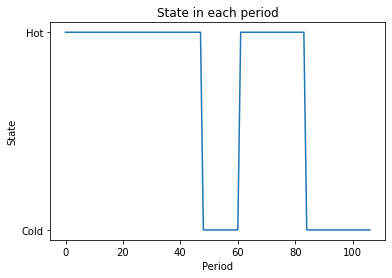

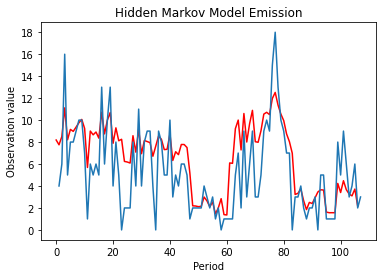

In [24]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(107),gp1_hmm.decode_matrix)
plt.show()

#Plot the mu_2 each month

plt.plot(range(107),state_specific_mu,'r')


#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
strikes_data['strikes'].plot()
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

**MAE**

In [25]:
np.abs(state_specific_mu-strikes_data['strikes']).mean()

2.623234501123665

**AIC**

In [26]:
-(gp1_hmm.ll_history[-1])*2+gp1_hmm.start_params.shape[0]*2

array([542.18121802])

In [27]:
gp1_hmm.alpha

array([[-0.18544045],
       [-0.03858375]])

In [28]:
gp1_hmm.compute_GP1_alpha()

In [29]:
gp1_hmm.alpha

array([[0.04771325],
       [0.06965042]])